In [1]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver

from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain.messages import RemoveMessage

In [12]:
load_dotenv()

True

In [2]:
load_dotenv()
from langchain_groq import ChatGroq
# Model
model = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0.1)

In [3]:
def chat(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

def delete_old_messages(state: MessagesState):
    msgs = state["messages"]

    # if more than 10 messages, delete the earliest 6
    if len(msgs) > 10:
        to_remove = msgs[:6]
        return {"messages": [RemoveMessage(id=m.id) for m in to_remove]}

    return {}

In [4]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat)
builder.add_node("cleanup", delete_old_messages)

In [5]:
builder.add_edge(START, "chat")
builder.add_edge("chat", "cleanup")   # run deletion after each response
builder.add_edge("cleanup", "__end__")

In [6]:
graph = builder.compile(checkpointer=InMemorySaver())

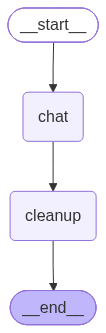

In [7]:
graph

In [14]:
config = {"configurable": {"thread_id": "t1"}}
confi2 = {"configurable": {"thread_id": "t2"}}

In [15]:
# Run multiple turns
graph.invoke({"messages": [{"role": "user", "content": "Hi, I'm Sujat"}]}, confi2)
graph.invoke({"messages": [{"role": "user", "content": "Tell me about LangGraph explaiin under 50 words"}]}, confi2)
graph.invoke({"messages": [{"role": "user", "content": "Now explain checkpointers explaiin under 50 words"}]}, confi2)
graph.invoke({"messages": [{"role": "user", "content": "What is Langchain explaiin under 50 words"}]}, confi2)
graph.invoke({"messages": [{"role": "user", "content": "What is Quantum Mechanics explaiin under 50 words"}]}, confi2)
graph.invoke({"messages": [{"role": "user", "content": "What is Gen AI explaiin under 50 words"}]}, confi2)
graph.invoke({"messages": [{"role": "user", "content": "What is my name"}]}, confi2)

{'messages': [HumanMessage(content='What is Langchain explaiin under 50 words', additional_kwargs={}, response_metadata={}, id='f72dfebd-a945-4518-9431-3c179706cf81'),
  AIMessage(content='LangChain is a Python library that simplifies building applications powered by large language models. It provides modular components—prompts, memory, agents, tools, and data connectors—so developers can chain LLM calls, manage context, and integrate external APIs to create robust, programmable AI workflows.', additional_kwargs={'reasoning_content': 'User asks: "What is Langchain explaiin under 50 words". Need to give concise definition under 50 words. Provide answer.'}, response_metadata={'token_usage': {'completion_tokens': 96, 'prompt_tokens': 276, 'total_tokens': 372, 'completion_time': 0.199142599, 'completion_tokens_details': {'reasoning_tokens': 30}, 'prompt_time': 0.013162796, 'prompt_tokens_details': None, 'queue_time': 0.397373922, 'total_time': 0.212305395}, 'model_name': 'openai/gpt-oss-12

In [16]:
snap = graph.get_state(config)
print("Stored messages after cleanup:", len(snap.values["messages"]))

Stored messages after cleanup: 12


In [17]:
response = graph.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Hi, I'm Sujat"
            }
        ]
    },
    config
)

print(response["messages"][-1].content)

APIStatusError: Error code: 413 - {'error': {'message': 'Request too large for model `openai/gpt-oss-120b` in organization `org_01ksefjmdpfn7bhpfb313hat9j` service tier `on_demand` on tokens per minute (TPM): Limit 8000, Requested 8817, please reduce your message size and try again. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}